### Libaraies

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (6, 4)

import os
import yaml

import warnings
warnings.filterwarnings('ignore')


### Step 1: Load Training Data Only

In [2]:
config_file = os.path.join('..', 'config', 'config.yaml')

# Load config
with open(config_file, "r") as f:
    config = yaml.safe_load(f)

root_dir = (os.path.dirname(os.path.dirname(os.path.abspath(config_file))))
splits_path = os.path.join(root_dir, config['paths']['splits_data'])

print("The Data Splits will be saved to:", splits_path)

The Data Splits will be saved to: c:\Users\DELL\Desktop\loan-risk-system\data/splits/


In [3]:
X_train_cls = pd.read_csv(os.path.join(splits_path, "X_train_cls.csv"))
y_train_cls = pd.read_csv(os.path.join(splits_path, "y_train_cls.csv"))
print("X_train_cls shape:", X_train_cls.shape)
print("y_train_cls shape:", y_train_cls.shape)

X_train_cls shape: (27693, 11)
y_train_cls shape: (27693, 1)


In [4]:
Train_cls_df = pd.concat([X_train_cls, y_train_cls], axis=1)
print(f"Train Classification Set: {Train_cls_df.shape[0]} samples, {Train_cls_df.shape[1]} features")

Train Classification Set: 27693 samples, 12 features


###  Step 2: Copy Dataset 

In [5]:
df_eda = Train_cls_df.copy()
print(df_eda.shape)

(27693, 12)


### Step 3: Basic Operations

In [6]:
print("Shape:", df_eda.shape)

Shape: (27693, 12)


In [7]:
df_eda.head(2)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,28,135000,RENT,5.0,VENTURE,B,4000,12.42,0.03,N,5,0
1,26,60000,RENT,3.0,DEBTCONSOLIDATION,B,3000,10.00,0.05,N,3,0


In [8]:
df_eda.tail(2)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
27691,29,110000,RENT,4.0,HOMEIMPROVEMENT,E,24000,18.39,0.22,Y,8,0
27692,28,60000,RENT,2.0,PERSONAL,B,12000,12.18,0.20,N,10,0


In [9]:
df_eda.sample(2)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
20670,39,126000,MORTGAGE,3.0,MEDICAL,B,14000,9.99,0.11,N,14,0
14660,35,45000,RENT,4.0,PERSONAL,C,5200,13.06,0.12,Y,10,0


In [10]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27693 entries, 0 to 27692
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  27693 non-null  int64  
 1   person_income               27693 non-null  int64  
 2   person_home_ownership       27693 non-null  object 
 3   person_emp_length           26915 non-null  float64
 4   loan_intent                 27693 non-null  object 
 5   loan_grade                  27693 non-null  object 
 6   loan_amnt                   27693 non-null  int64  
 7   loan_int_rate               25047 non-null  float64
 8   loan_percent_income         27693 non-null  float64
 9   cb_person_default_on_file   27693 non-null  object 
 10  cb_person_cred_hist_length  27693 non-null  int64  
 11  loan_status                 27693 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 2.5+ MB


In [11]:
df_eda.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,27693.000000,2.769300e+04,26915.000000,27693.000000,25047.000000,27693.000000,27693.000000,27693.000000
mean,27.708302,6.597286e+04,4.785138,9579.248366,11.015674,0.170326,5.790561,0.218178
std,6.331659,6.271022e+04,4.167057,6302.999498,3.235679,0.106821,4.042214,0.413016
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,23.000000,3.848200e+04,2.000000,5000.000000,7.900000,0.090000,3.000000,0.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.150000,4.000000,0.000000
75%,30.000000,7.900000e+04,7.000000,12100.000000,13.480000,0.230000,8.000000,0.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,22.480000,0.830000,30.000000,1.000000


In [12]:
# Skewness Interpretation:
# <0.5 --> Normal , 0.5to1.0 --> Moderate skew , >1.0 --> High skew , >2.0 --> Extreme skew 
df_eda.skew(numeric_only=True)

person_age                     2.705253
person_income                 35.694767
person_emp_length              2.837094
loan_amnt                      1.192506
loan_int_rate                  0.199957
loan_percent_income            1.065126
cb_person_cred_hist_length     1.663755
loan_status                    1.364801
dtype: float64

In [13]:
# If a feature has very high kurtosis, it likely has fat tails. That means rare but extreme values
df_eda.kurtosis(numeric_only=True)

person_age                      21.098996
person_income                 2988.100026
person_emp_length               49.952148
loan_amnt                        1.442595
loan_int_rate                   -0.682946
loan_percent_income              1.234987
cb_person_cred_hist_length       3.725649
loan_status                     -0.137329
dtype: float64

###  Step 4: Missing Values Visualization

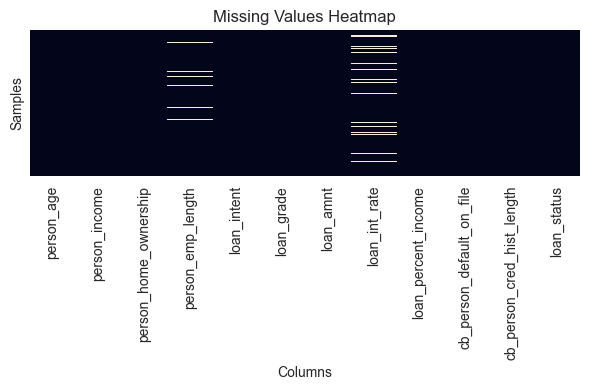

In [17]:
# Heatmap → shows WHERE missing values are located in dataset

sns.heatmap(df_eda.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Values Heatmap')
plt.xlabel('Columns')
plt.ylabel('Samples')
plt.tight_layout()
plt.savefig('../logs/reports/figures/missing_values_heatmap.png')
plt.show()

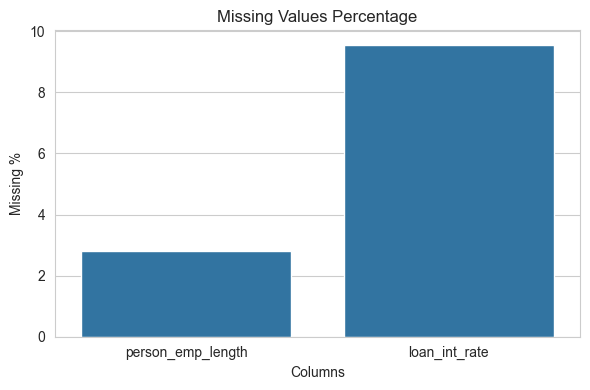

In [ ]:
# Barplot → shows HOW MUCH missing values per column

missing_values = df_eda.isnull().sum()[df_eda.isnull().sum() > 0] / len(df_eda) * 100 

sns.barplot(x=missing_values.index, y=missing_values.values)
plt.title('Missing Values Percentage')
plt.xlabel('Columns')
plt.ylabel('Missing %')
plt.tight_layout()
plt.savefig('../logs/reports/figures/missing_values_bar.png')
plt.show()

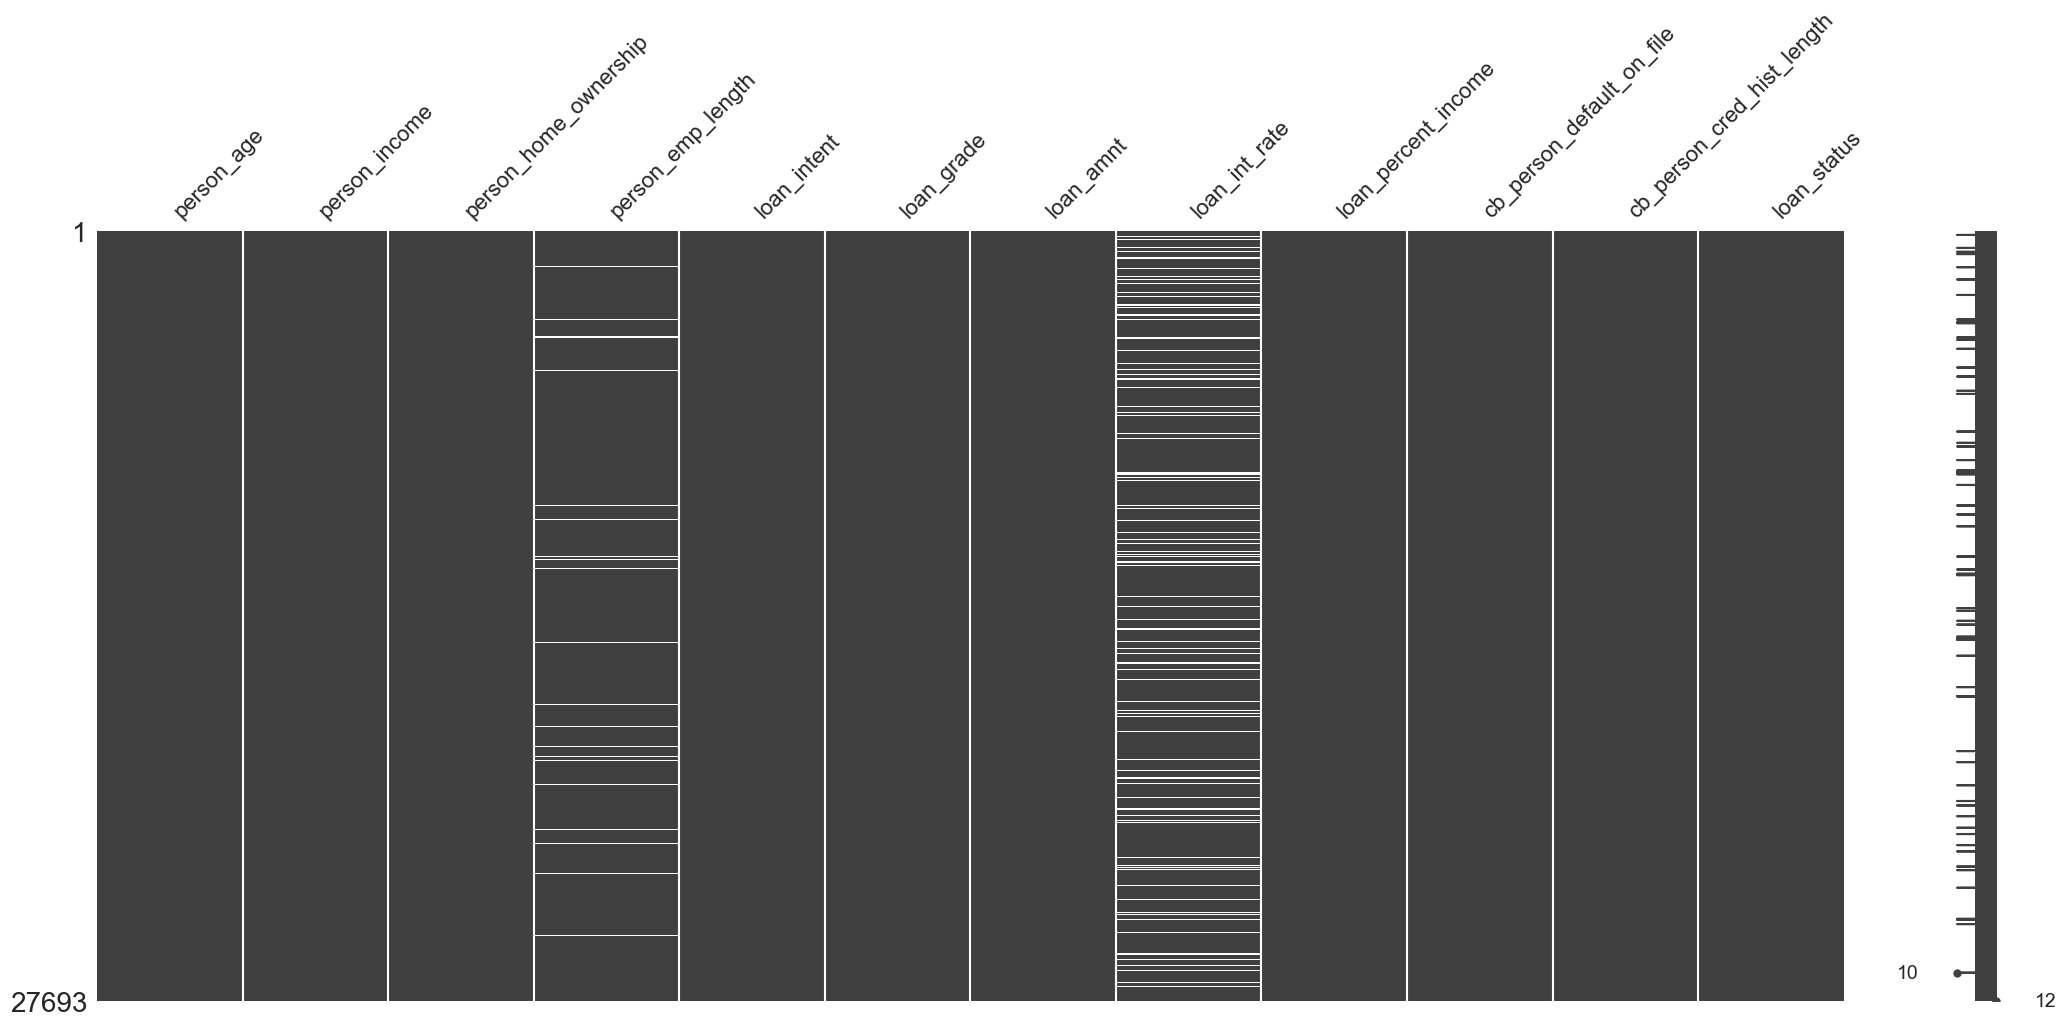

In [36]:
# Better Choice than seaborn heatmap and barplot for missing values visualization is the missingno library
# which provides more informative visualizations for missing data patterns.
msno.matrix(df_eda)
plt.savefig('../logs/reports/figures/missing_data_matrix.png')
plt.show()

### Step 5: Targets Distribution Analysis (loan_status and loan_int_rate)

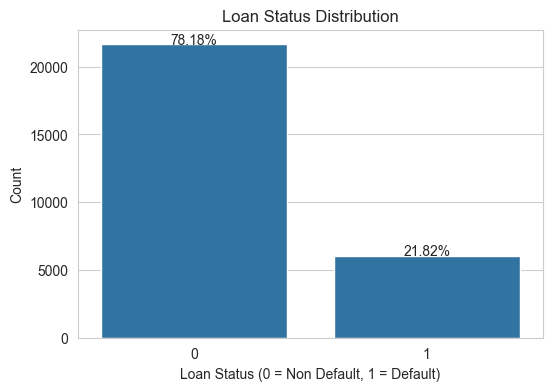

In [40]:
# Count
# plot -— shows class counts for the target variable (loan_status)

# Plot countplot
ax = sns.countplot(data=df_eda, x='loan_status'   )
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status (0 = Non Default, 1 = Default)')
plt.ylabel('Count')

# 2. Add percentage annotations on each bar
total = len(df_eda)
# Loop through each bar
for bar in ax.patches:
    count = bar.get_height()
    percentage = (count / total) * 100
    
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        count,
        f'{percentage:.2f}%',
        ha='center'
    )

# 3. Save and show
plt.savefig('../logs/reports/figures/loan_status_distribution.png')
plt.show()

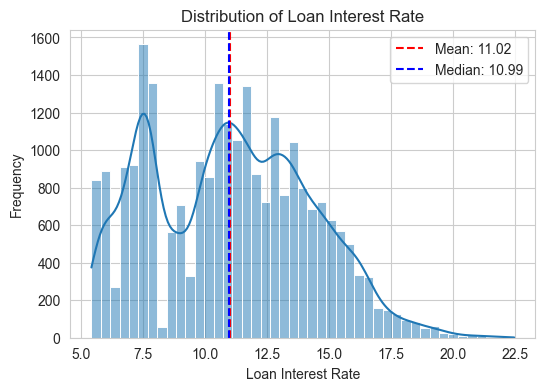

In [41]:
# Histogram + KDE  -— shows distribution of a numerical feature, along with a smoothed curve (KDE) to visualize the underlying distribution shape.

# 1. Plot histogram with KDE
sns.histplot(data=df_eda, x='loan_int_rate', kde=True)

# 2. Add vertical line for mean
mean = df_eda['loan_int_rate'].mean()
plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.2f}')

# 3. Add vertical line for median
median = df_eda['loan_int_rate'].median()
plt.axvline(median, color='blue', linestyle='--', label=f'Median: {median:.2f}')

plt.title('Distribution of Loan Interest Rate')
plt.xlabel('Loan Interest Rate')
plt.ylabel('Frequency')
plt.legend()

plt.savefig('../logs/reports/figures/loan_int_rate_distribution.png')
plt.show()

In [ ]:
# Insight:
'''
Key Insight from Plot 2:

Two peaks suggest two groups of borrowers
Low rate group (~7-8%) → low risk borrowers
High rate group (~11-13%) → higher risk borrowers
This pattern will help in clustering model to make cluster 
'''

###  Step 6: Numerical Features Distribution

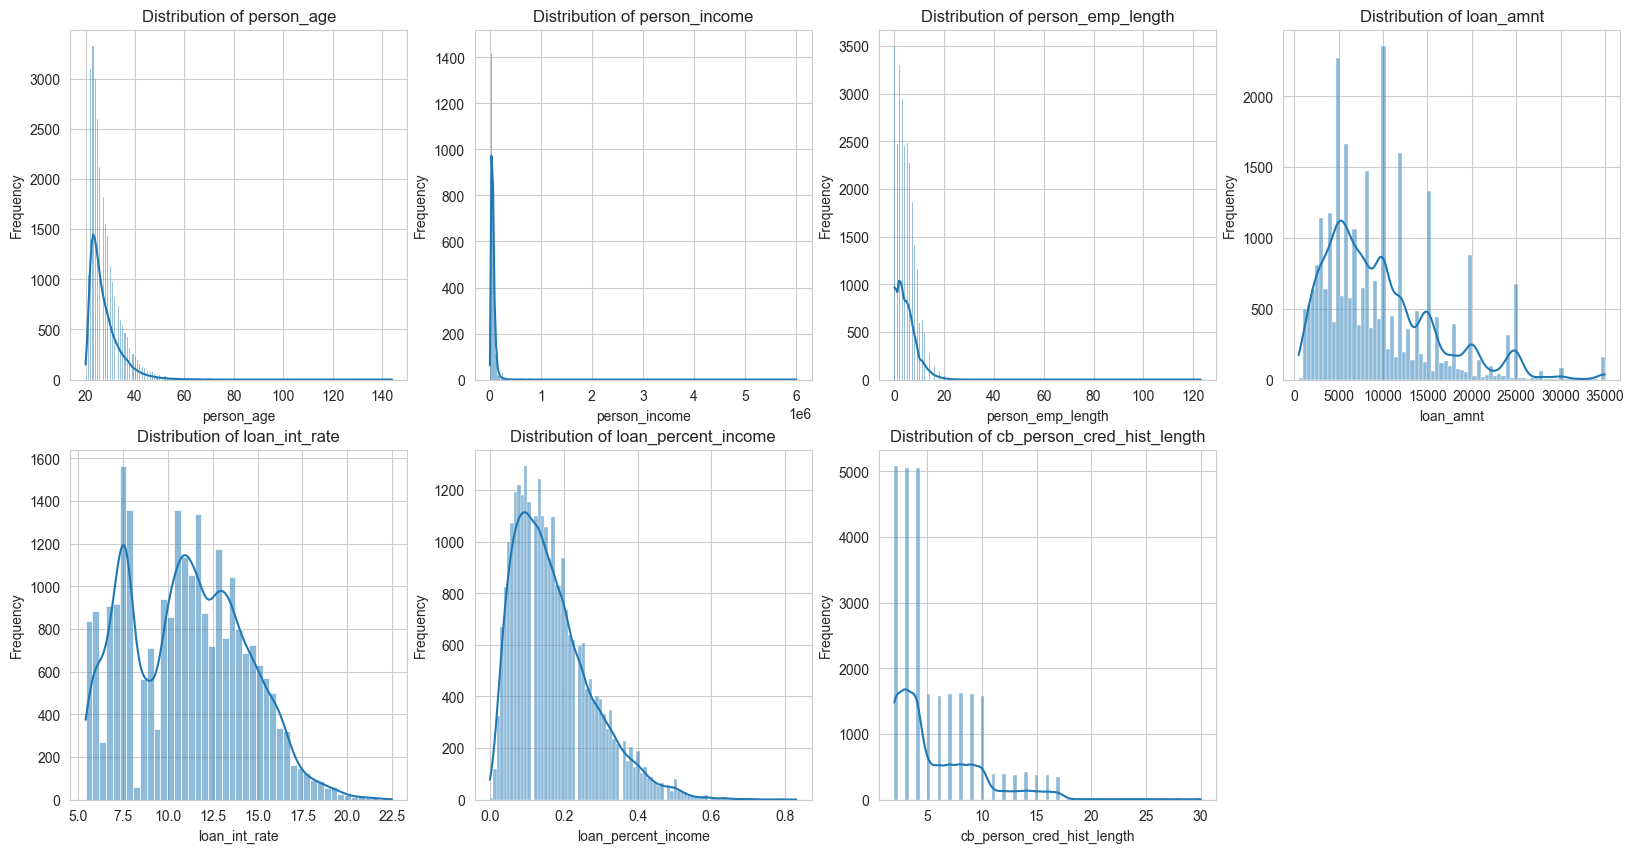

In [ ]:
# KDE + Histogram Plot: shows distribution of numerical features, highlighting the shape of the distribution and potential skewness or multimodality.

numerical_cols = ['person_age', 'person_income', 
                  'person_emp_length', 'loan_amnt',
                  'loan_int_rate', 'loan_percent_income',
                  'cb_person_cred_hist_length'] # total 7 numerical features

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten() # It reshapes that 2D structure into a single 1D array

for i, col in enumerate(numerical_cols):
    sns.histplot(df_eda[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[-1].set_visible(False)
    
plt.savefig('../logs/reports/figures/numerical_col_kde_distributions.png')
plt.show()

In [ ]:
'''
KDE + Histogram Plot:
Column                      Observation 

person_age                  Right skewed — most applicants 20-35 
person_income               Extremely right skewed — needs log transform
person_emp_length           Right skewed — most 0-10 years 
loan_amnt                   Multiple peaks — different loan categories 
loan_int_rate               Bimodal — 2 borrower groups confirmed 
loan_percent_income         Right skewed 
cb_person_cred_hist_length  Right skewed
'''

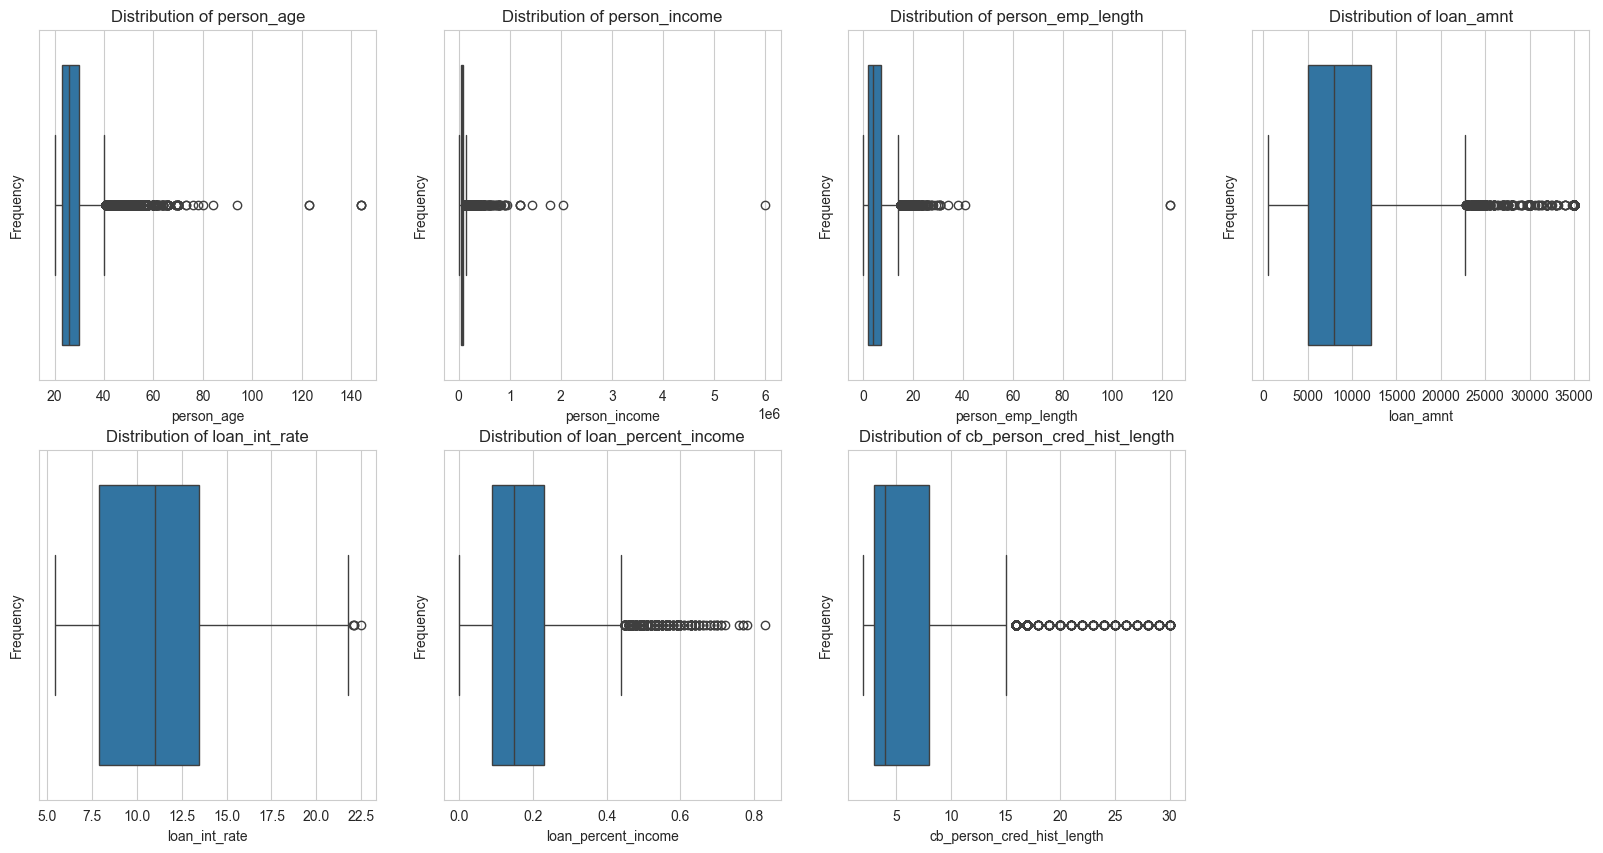

In [43]:
# boxplot: shows distribution of numerical features, highlighting median, quartiles, and potential outliers.

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df_eda[col], ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[-1].set_visible(False)
    
plt.savefig('../logs/reports/figures/numerical_col_boxplots_distributon.png')
plt.show()

In [ ]:
'''
Boxplot:
Column                      Observation 

person_age                  Clear outliers above 80
person_income               Extreme outliers visible
person_emp_length           Outliers above 40
loan_percent_income         Many outliers
cb_person_cred_hist_length  Many outliers
'''

### Step 7: Categorical Features Distribution

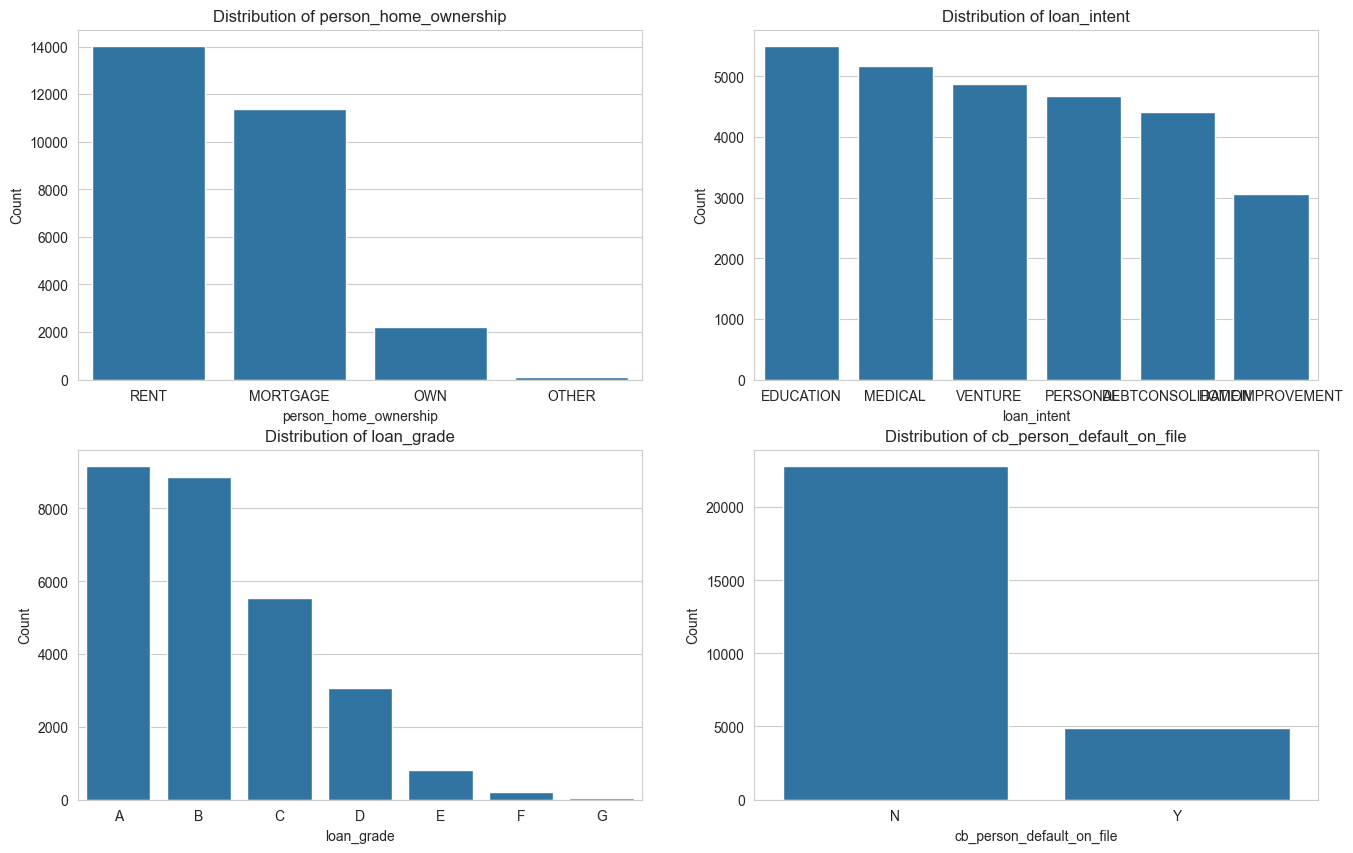

In [45]:
# coutplot: shows class counts for categorical features, highlighting the distribution of categories and potential imbalances.

categorical_cols = ['person_home_ownership', 'loan_intent',
                    'loan_grade', 'cb_person_default_on_file']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i , col in enumerate(categorical_cols):
    sns.countplot(data=df_eda , x=col , ax=axes[i], order=df_eda[col].value_counts().index)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')


plt.savefig('../logs/reports/figures/categorical_col_countplots_distribution.png')
plt.show()

In [ ]:
'''
Countplots:
ColumnKey                   Finding
person_home_ownership       RENT dominant (50%)
loan_intent                 Education highest, fairly balanced
loan_grade                  A & B dominant — mostly good borrowers
cb_person_default_on_file   82% no history of default -- good sign for low risk
'''

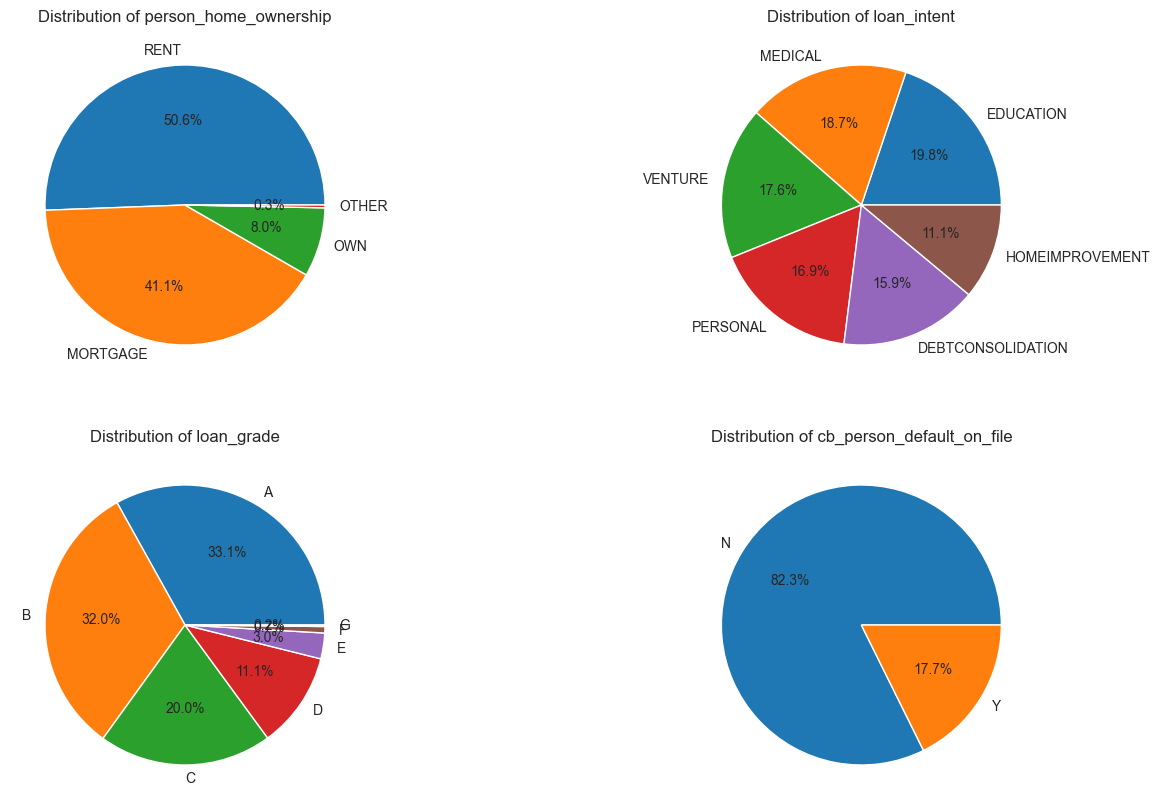

In [49]:
# pie chart: shows percentage distribution of categories for categorical features, highlighting the proportion of each category within the feature.

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i , col in enumerate(categorical_cols):
    value_counts = df_eda[col].value_counts()
    axes[i].pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%')
    axes[i].set_title(f'Distribution of {col}')

plt.savefig('../logs/reports/figures/categorical_col_pie_distribution.png')
plt.show()

In [ ]:
'''
Key Business Insights from Step 7:

Most applicants are renters — higher risk group
A & B grade loans dominate — good sign
Only 17.7% have past default history
Loan intents are fairly balanced — no single dominant purpose'''

###  Step 8: Outlier Visualization

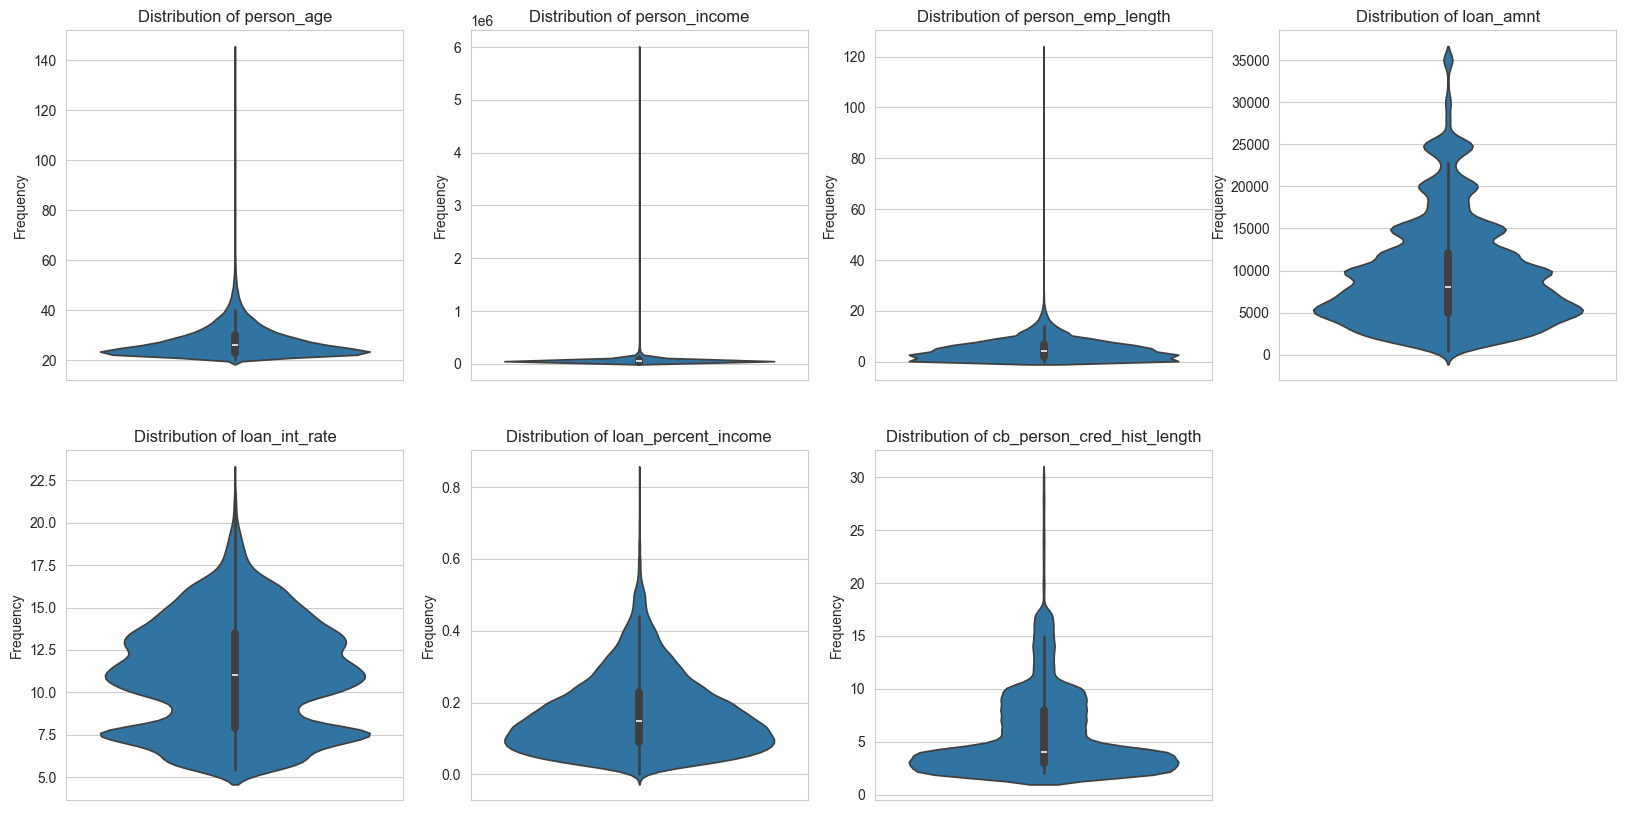

In [50]:
# violin plot: shows distribution of numerical features, highlighting the density and potential outliers.

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.violinplot(data=df_eda, x=None, y=col, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel('Frequency')
    axes[-1].set_visible(False)
plt.savefig('../logs/reports/figures/numerical_col_violin_outlier.png')
plt.show()

In [ ]:
'''
Violin Plots:
Column                      Observation

person_age                  Long tail upward — outliers confirmed
person_income               Extremely long tail — severe outliers
person_emp_length           Long tail upward
loan_amnt                   Multiple bumps — different loan sizes
loan_int_rate               Nice bimodal shape — 2 borrower groups
loan_percent_income         Right skewed
cb_person_cred_hist_length  Right skewed'''


In [ ]:
# Boxplot was already plotted in the previous cell, so we can skip it here.

In [ ]:
# Outlier Detection using IQR method:

outlier_summary = []

for col in numerical_cols:
    Q1 = df_eda[col].quantile(0.25)
    Q3 = df_eda[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_below = (df_eda[col] < lower_bound).sum()
    outliers_above = (df_eda[col] > upper_bound).sum()
    
    outlier_summary.append({
        'Column': col,
        'Outliers Below': outliers_below,
        'Outliers Above': outliers_above,
        'Total Outliers': outliers_below + outliers_above
    })
print("Outlier Summary:")

outlier_df = pd.DataFrame(outlier_summary)
outlier_df['Percentage'] = (outlier_df['Total Outliers'] / len(df_eda) * 100).round(2)
print(outlier_df.to_string(index=False))


Outlier Summary:
                    Column  Outliers Below  Outliers Above  Total Outliers  Percentage
                person_age               0            1221            1221        4.41
             person_income               0            1353            1353        4.89
         person_emp_length               0             736             736        2.66
                 loan_amnt               0            1454            1454        5.25
             loan_int_rate               0               4               4        0.01
       loan_percent_income               0             560             560        2.02
cb_person_cred_hist_length               0             953             953        3.44


### Step 9: Numerical vs Target Analysis

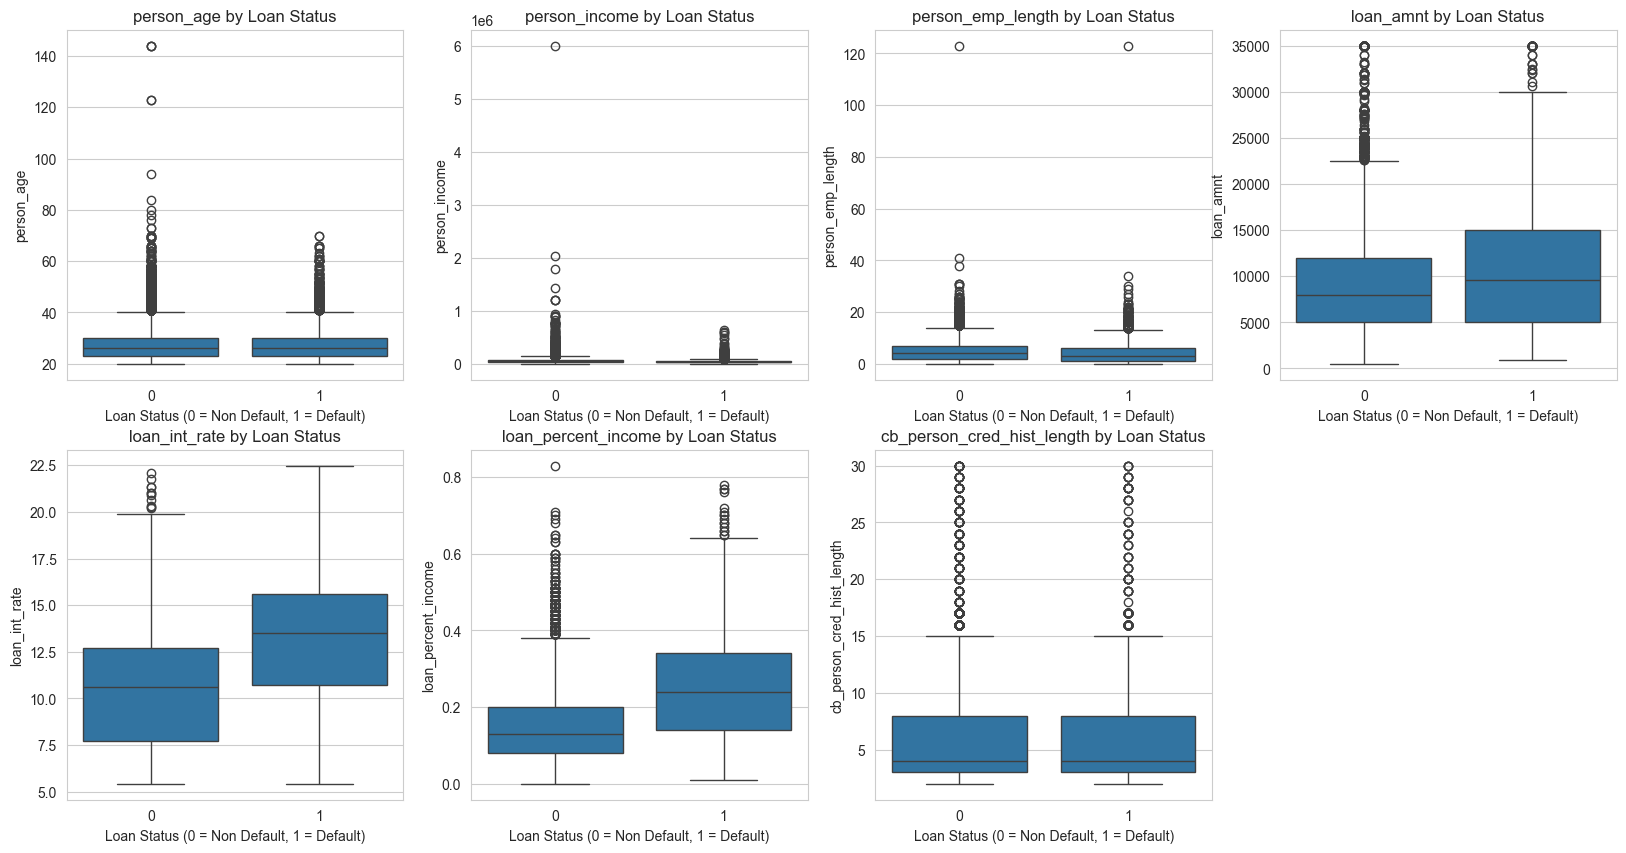

In [58]:
# boxplot by loan_status: shows distribution of numerical features across different loan status categories, 
# highlighting differences in central tendency and variability between default and non-default groups.

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df_eda, x='loan_status', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Loan Status')
    axes[i].set_xlabel('Loan Status (0 = Non Default, 1 = Default)')
    axes[i].set_ylabel(col)
    
    axes[-1].set_visible(False)
plt.savefig('../logs/reports/figures/numerical_col_boxplot_by_loan_status.png')
plt.show()

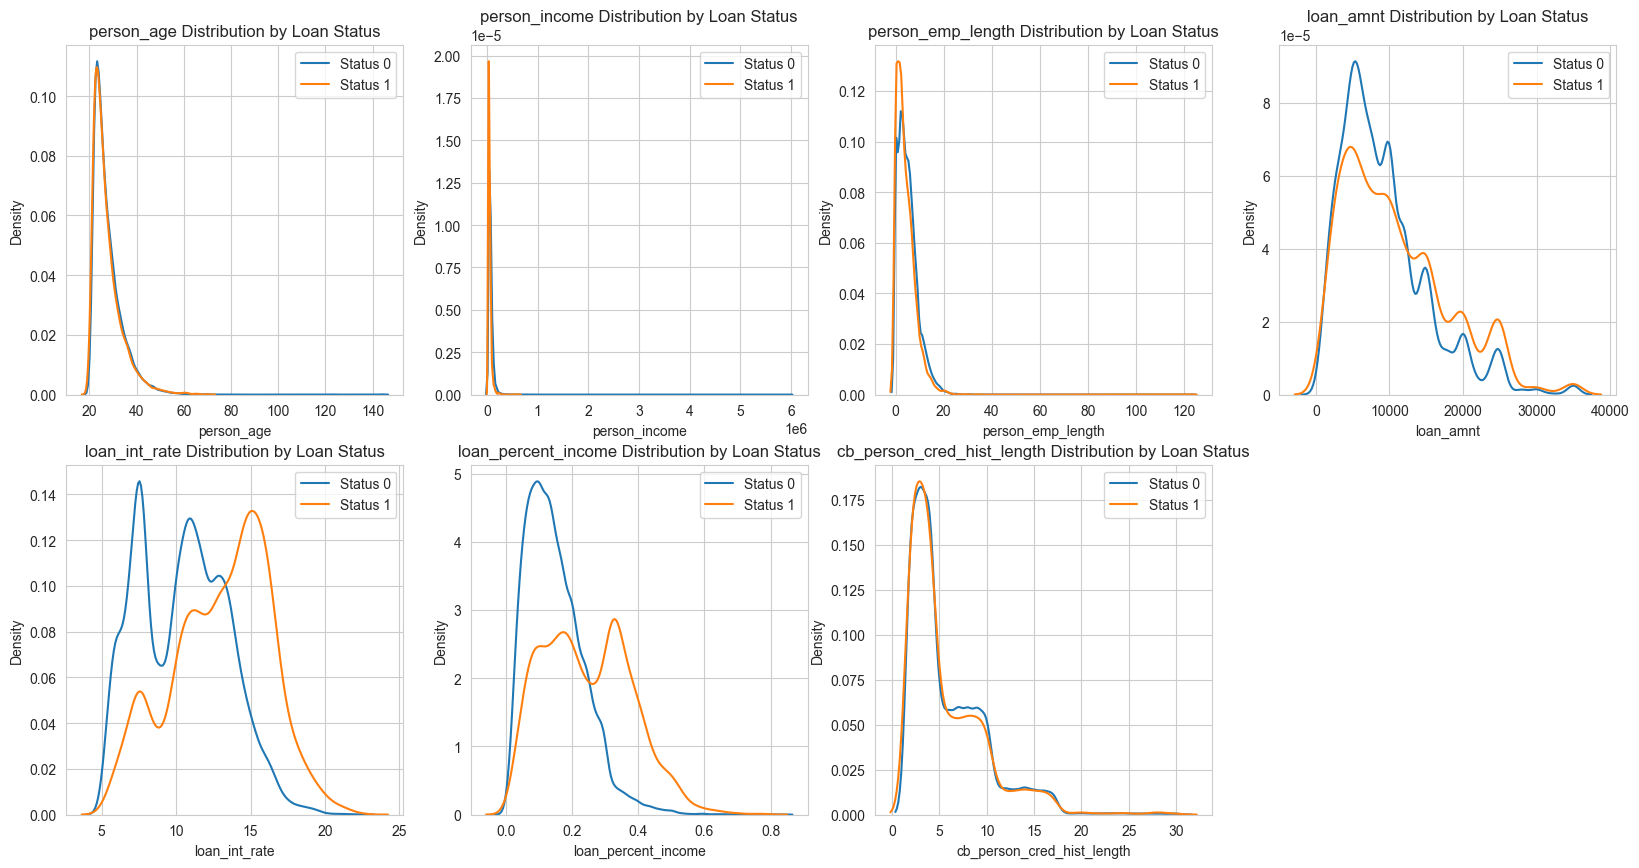

In [59]:
# KDE by loan_status: shows distribution of numerical features across different loan status categories,
# highlighting differences in distribution shape and central tendency between default and non-default groups.

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    for status in [0, 1]:
        subset = df_eda[df_eda['loan_status'] == status]
        sns.kdeplot(subset[col], ax=axes[i], label=f'Status {status}')
    axes[i].set_title(f'{col} Distribution by Loan Status')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[-1].set_visible(False)
    
plt.savefig('../logs/reports/figures/numerical_col_kde_by_loan_status.png')
plt.show()

In [ ]:
'''
Most Important Features for Classification:

Column                          Finding                               Useful?
loan_int_rate                   Clear separation between 0 and 1      Very useful
loan_percent_income             Defaulters have higher %              Very useful
loan_amnt                       Defaulters take larger loans          Useful
person_age                      Almost identical distributions        Less useful
person_income                   Very similar distributions            Less useful
person_emp_length               Almost identical                      Less useful
cb_person_cred_hist_length      Almost identical                      Less useful

Key Business Insights:

Higher interest rate → more likely to default
Higher loan % of income → more likely to default
Larger loan amount → slightly more likely to default'''

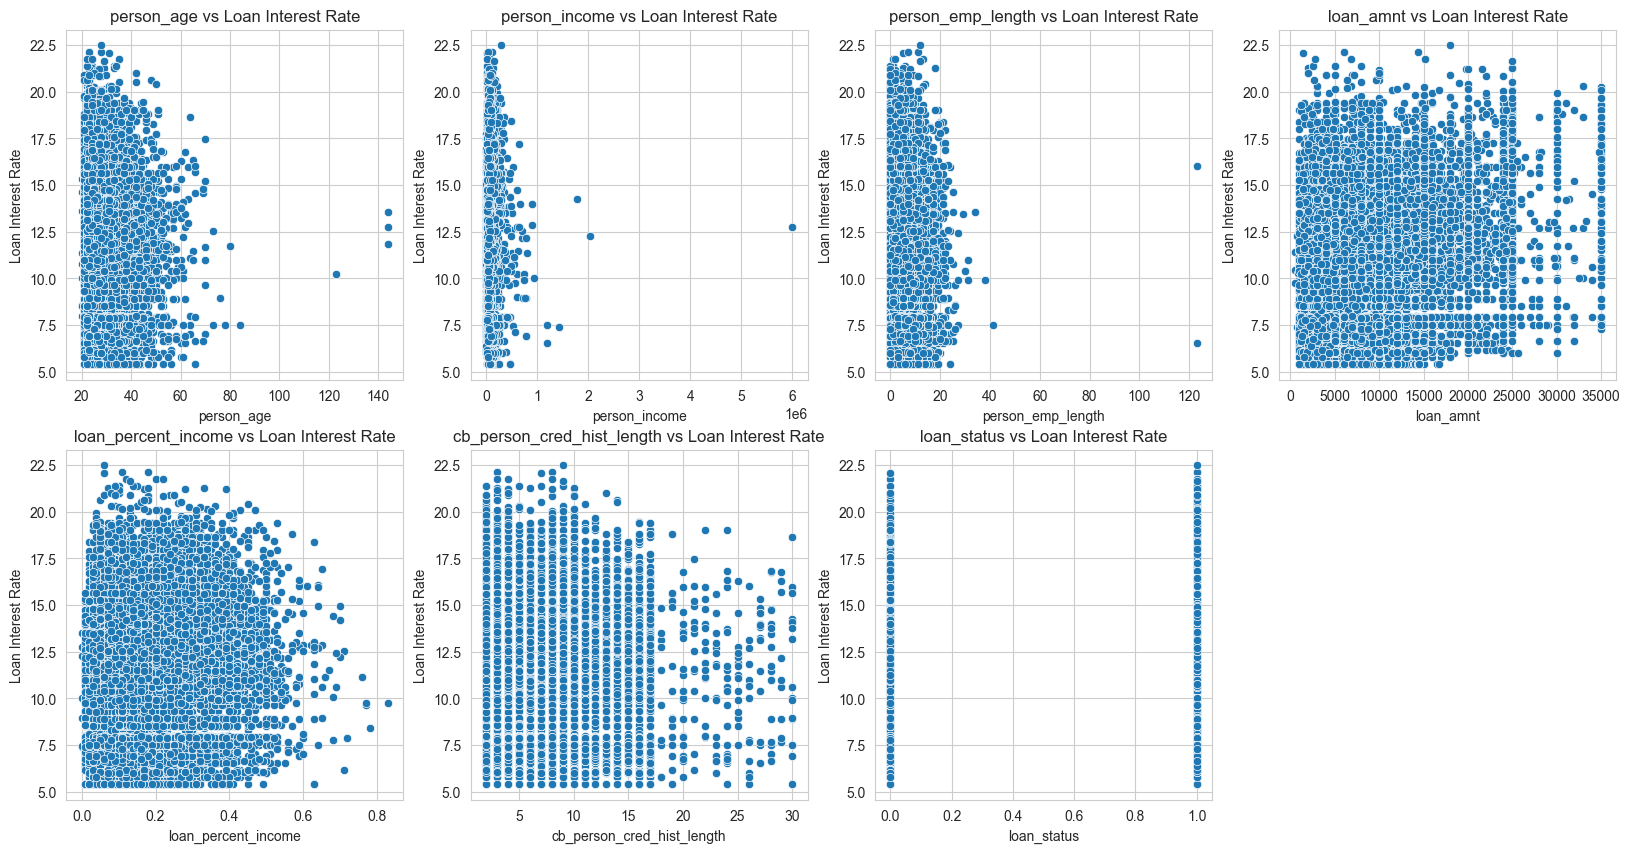

In [61]:
# Scatter plot by loan_int_rate : shows relationship between two numerical features, highlighting potential correlations or patterns.

# Remove loan_int_rate from numerical cols list
numerical_cols_reg = ['person_age', 'person_income', 
                  'person_emp_length', 'loan_amnt',
                  'loan_percent_income', 
                  'cb_person_cred_hist_length',"loan_status"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols_reg):
    sns.scatterplot(data=df_eda, x=col, y='loan_int_rate', ax=axes[i])
    axes[i].set_title(f'{col} vs Loan Interest Rate')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Loan Interest Rate')
    axes[-1].set_visible(False)

plt.savefig('../logs/reports/figures/numerical_col_scatter_loan_int_rate.png')
plt.show()

In [62]:
'''
Column                      Finding
person_age                  No clear relationship
person_income               No clear relationship
person_emp_length           No clear relationship
loan_amnt                   Slight positive relationship
cb_person_cred_hist_length  No clear relationship
loan_status                 Defaulted loans (1) tend to have higher interest rates'''

'\nColumn                      Finding\nperson_age                  No clear relationship\nperson_income               No clear relationship\nperson_emp_length           No clear relationship\nloan_amnt                   Slight positive relationship\ncb_person_cred_hist_length  No clear relationship\nloan_status                 Defaulted loans (1) tend to have higher interest rates'

### Step 10: Categorical vs Target Analysis

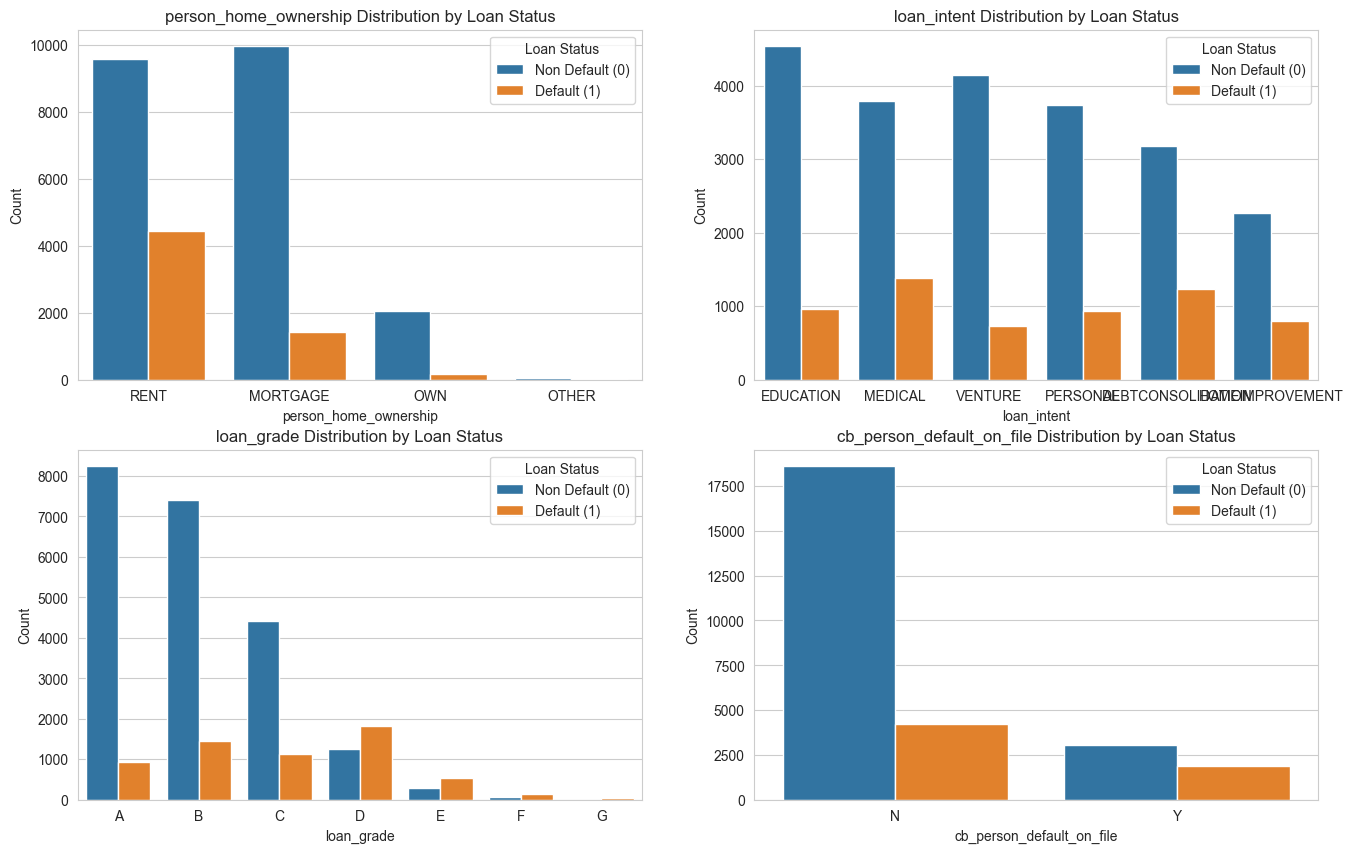

In [63]:
# countplot by loan_status: shows distribution of categorical features across different loan status categories,
# highlighting differences in category proportions between default and non-default groups.

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i , col in enumerate(categorical_cols):
    sns.countplot(data=df_eda , x=col , hue='loan_status', ax=axes[i], order=df_eda[col].value_counts().index)
    axes[i].set_title(f'{col} Distribution by Loan Status')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Loan Status', labels=['Non Default (0)', 'Default (1)'])
plt.savefig('../logs/reports/figures/categorical_col_countplot_by_loan_status.png')
plt.show()

In [ ]:
"""
Countplots:
Column                      Finding

person_home_ownership       RENT has highest defaults
loan_intent                 DEBTCONSOLIDATION highest defaults
loan_grade                  Lower grades (D,E,F,G) more defaults
cb_person_default_on_file   Y group has higher defaults
"""

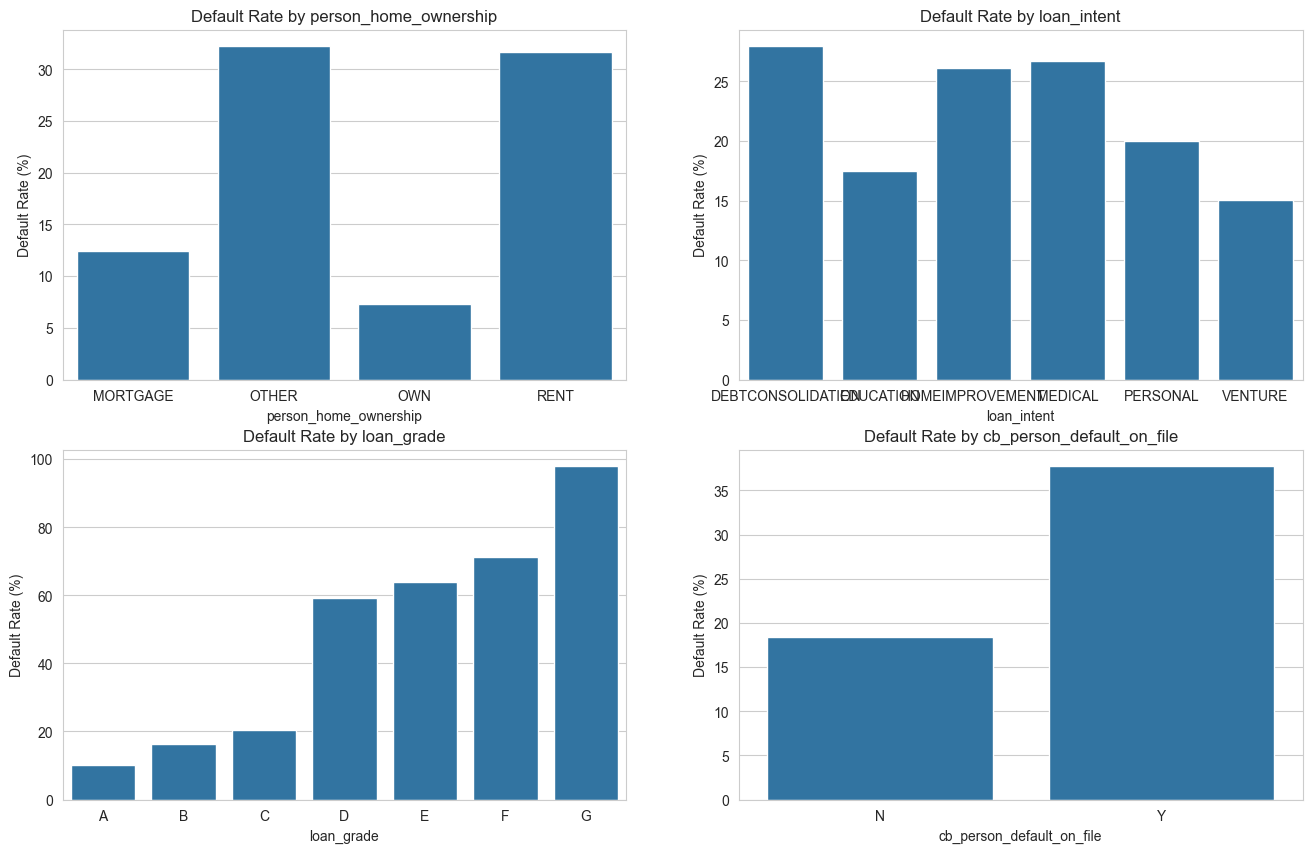

In [ ]:
# barplot by loan_status 

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i , col in enumerate(categorical_cols):
    default_rate = df_eda.groupby(col)['loan_status'].mean() * 100
    sns.barplot(x=default_rate.index, y=default_rate.values, ax=axes[i])
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Default Rate (%)')
plt.savefig('../logs/reports/figures/categorical_col_default_rate.png')
plt.show()

In [ ]:
'''
Default Rate Charts:
Column                            Key Insight

loan_grade                        G grade = 98% default rate! Strongest predictor
person_home_ownership             RENT=31%, MORTGAGE=12% — big difference
loan_intent                       DEBTCONSOLIDATION=27% highest risk intent
cb_person_default_on_file         People with past default history are 2x more likely to default again.Strong predictor.
'''

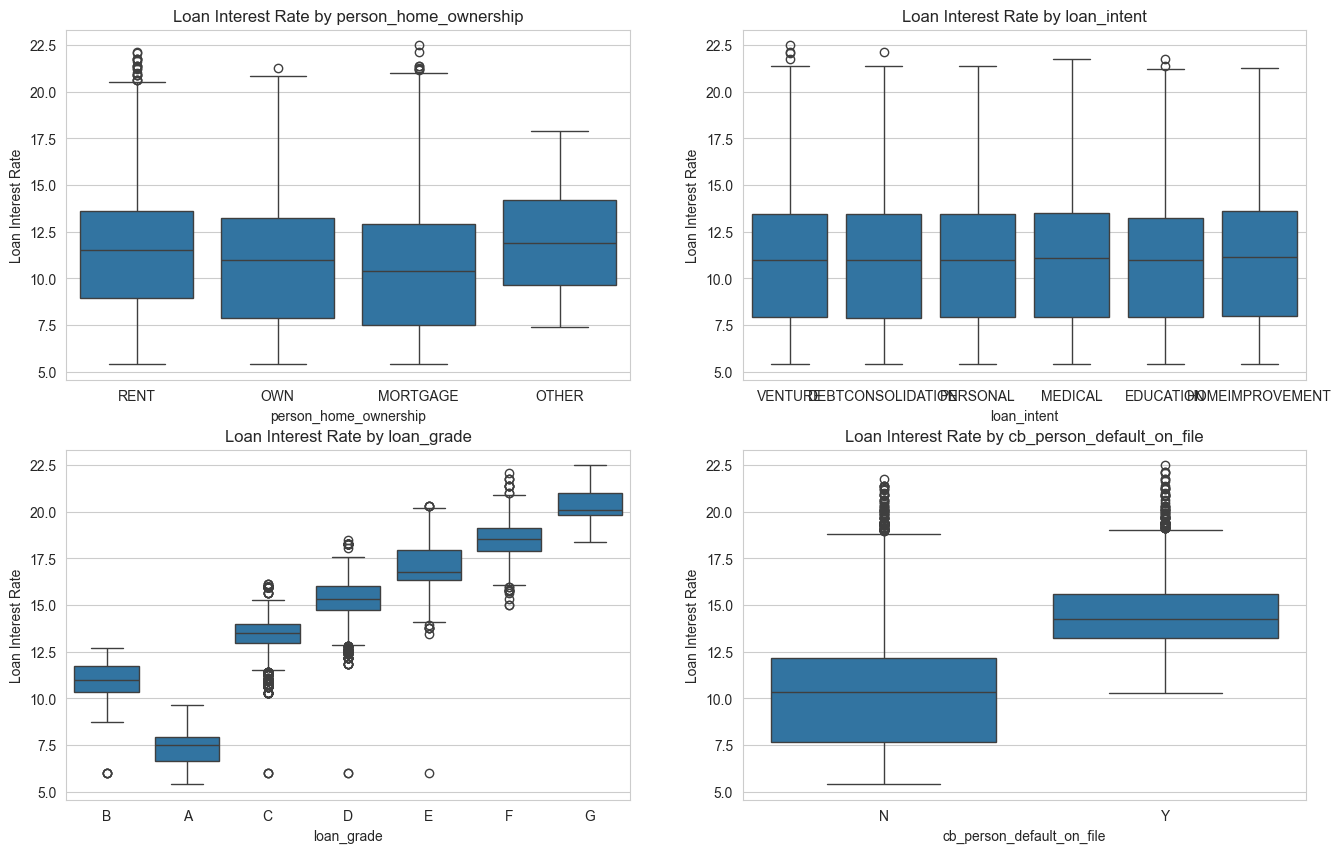

In [ ]:
# boxplot by loan_status: shows distribution of numerical features across different loan status categories

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i , col in enumerate(categorical_cols):
    sns.boxplot(data=df_eda, x=col, y='loan_int_rate', ax=axes[i])
    axes[i].set_title(f'Loan Interest Rate by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Loan Interest Rate')
    
plt.savefig('../logs/reports/figures/categorical_col_boxplot_loan_int_rate.png')
plt.show()

In [ ]:
'''
Column                      Finding

loan_grade                  Perfect pattern — A=lowest rate, G=highest rate. Strongest predictor for regression
cb_person_default_on_file   Y group has higher interest rate
person_home_ownership       Very similar distributions — weak predictor
loan_intent                 Almost identical across all intents — weak predictor

Most Important Insight:
loan_grade shows a perfect staircase pattern — each grade has clearly higher interest rate than previous. 
This confirms loan_grade is the strongest feature for regression model.'''

### Step 11: Correlation Heatmap

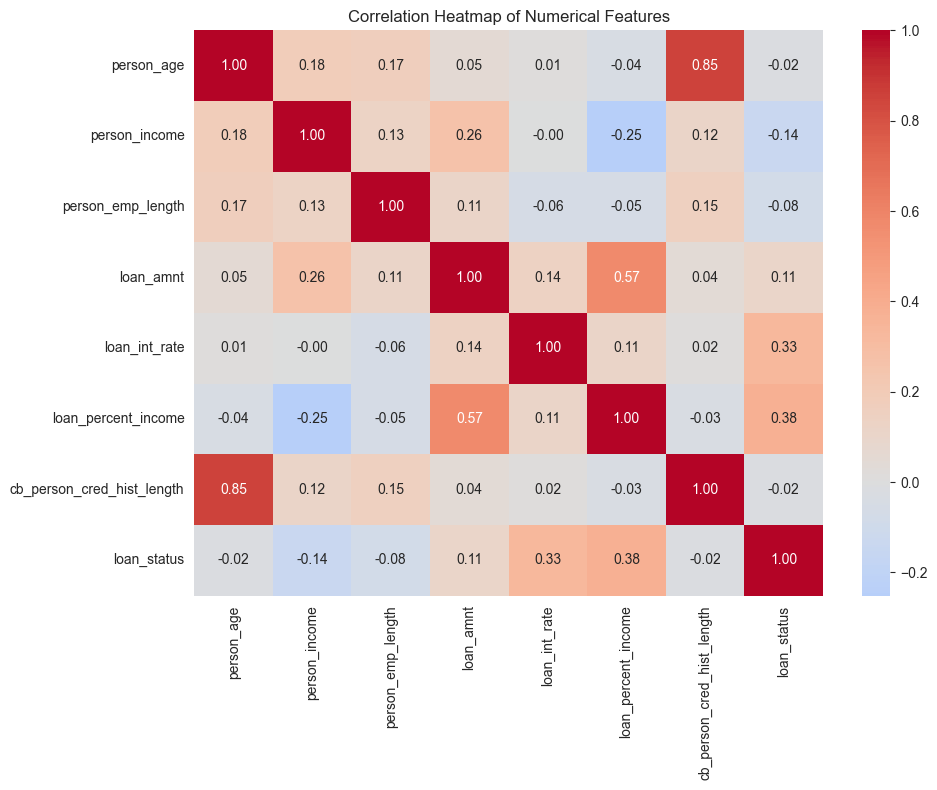

In [65]:
# heatmap

plt.figure(figsize=(10, 8))

corr_matrix = df_eda.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt='.2f',cmap='coolwarm', center=0)

plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.savefig('../logs/reports/figures/correlation_heatmap.png')
plt.show()

In [ ]:
'''
Correlation Heatmap:
Finding                                      Value           Action
person_age & cb_person_cred_hist_length      0.85            High correlation — drop one in FE
loan_amnt & loan_percent_income              0.57            Moderate correlation
loan_percent_income & loan_status            0.38            Strongest numerical predictor
loan_int_rate & loan_status                  0.33            Second strongest'''

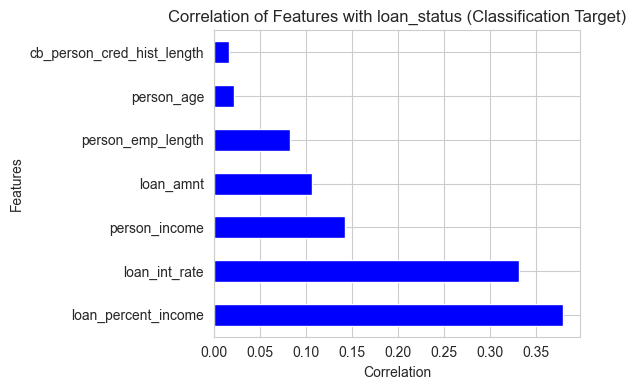

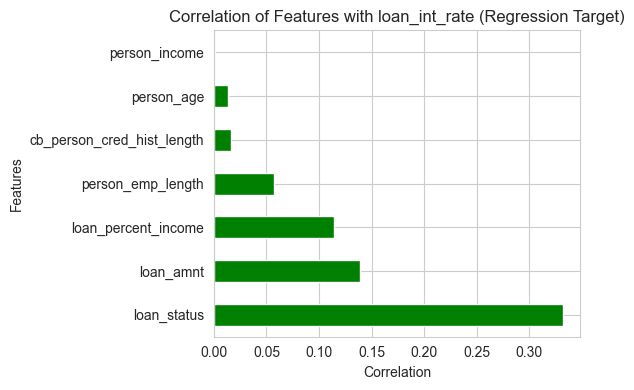

In [68]:
# Calculate correlation with each target
corr_with_status = df_eda.corr(numeric_only=True)['loan_status'].drop('loan_status')
corr_with_rate = df_eda.corr(numeric_only=True)['loan_int_rate'].drop('loan_int_rate')

corr_with_status = corr_with_status.abs().sort_values(ascending=False)
corr_with_rate = corr_with_rate.abs().sort_values(ascending=False)

corr_with_status.plot(kind='barh', color='blue')
plt.title('Correlation of Features with loan_status (Classification Target)')
plt.xlabel('Correlation')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('../logs/reports/figures/corr_with_loan_status.png')
plt.show()

corr_with_rate.plot(kind='barh', color='green')
plt.title('Correlation of Features with loan_int_rate (Regression Target)')
plt.xlabel('Correlation')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('../logs/reports/figures/corr_with_loan_int_rate.png')
plt.show()

In [ ]:
'''
Classification Target Correlations:
Feature                 Correlation
loan_percent_income     0.38
loan_int_rate           0.33
person_income           0.14 
Rest                    < 0.10'''

'''
Regression Target Correlations:
Feature                 Correlation
loan_status             0.33 
loan_amnt               0.14
loan_percent_income     0.11
Rest                    < 0.10'''

###  Step 12: Key Feature Relationships (Pairplot)

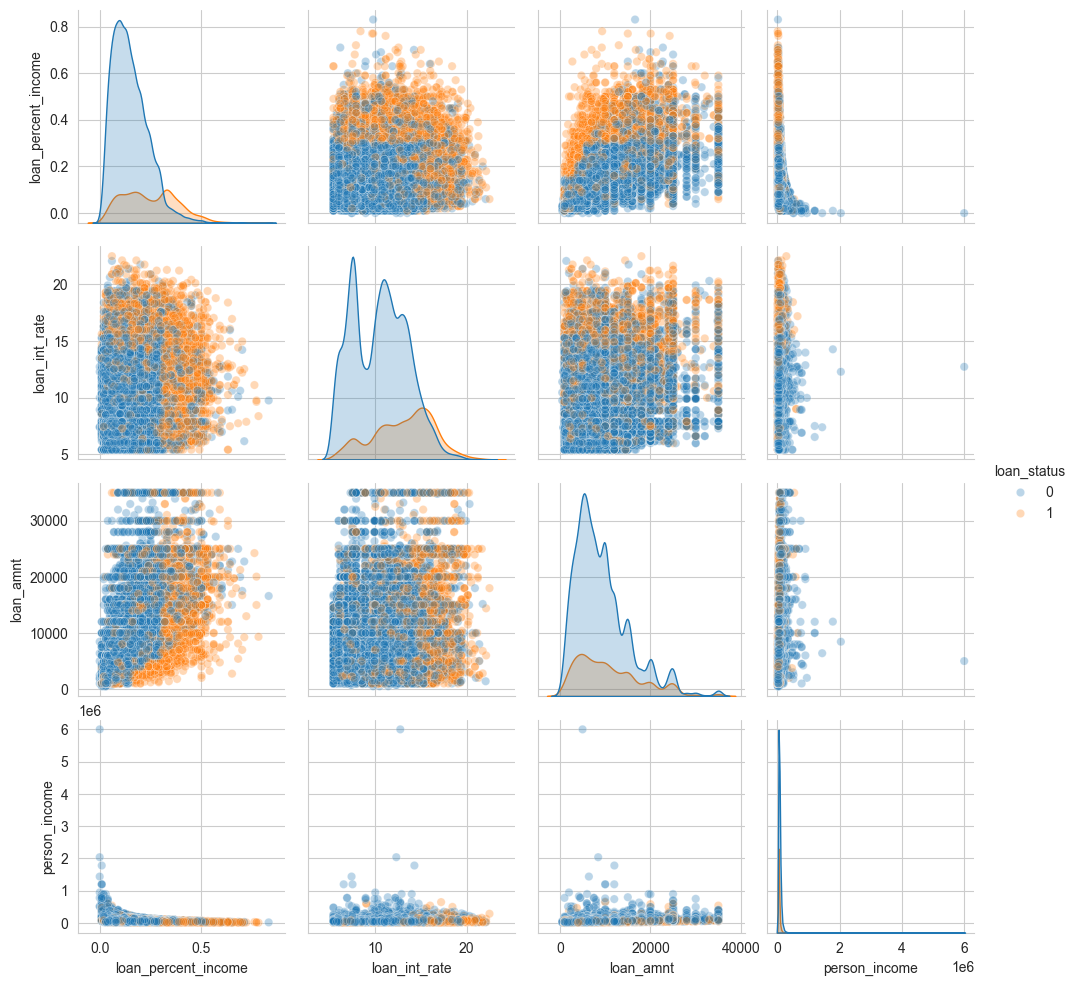

In [ ]:
important_cols = ['loan_percent_income', 'loan_int_rate', 
                  'loan_amnt', 'person_income', 'loan_status'] # come from previous step

sns.pairplot(df_eda[important_cols], hue='loan_status', plot_kws={'alpha': 0.3})
plt.savefig('../logs/reports/figures/pairplot_important_features.png')  
plt.show()

In [ ]:
"""
Pairplot:
Finding                         Insight

loan_percent_income             Clear separation between 0 and 1
loan_int_rate                   Defaulters (orange) shift to higher rates
person_income                   Extreme outliers visible — needs log transform
loan_amnt                       Defaulters take larger loans"""

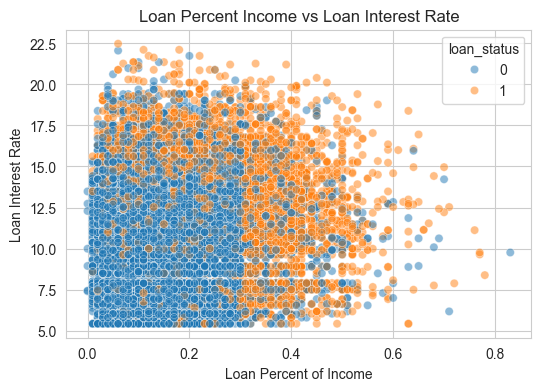

In [69]:
# Plot loan_percent_income vs loan_int_rate
# Color by loan_status
# This is the most important relationship found

sns.scatterplot(data=df_eda, x='loan_percent_income', y='loan_int_rate', hue='loan_status', alpha=0.5)
plt.title('Loan Percent Income vs Loan Interest Rate')
plt.xlabel('Loan Percent of Income')
plt.ylabel('Loan Interest Rate')
plt.savefig('../logs/reports/figures/loan_percent_income_vs_loan_int_rate.png')
plt.show()

In [ ]:
"""
Scatterplot:
Finding                                             Insight
Low percent income + Low interest                   Mostly non-default (blue) 
High percent income + High interest               Mostly default (orange) 
Clear diagonal boundary visible                   These 2 features together separate classes well 
"""

#Key Business Insight:
#When a borrower spends more than 40% of income on loan AND has high interest rate — default risk is very high.

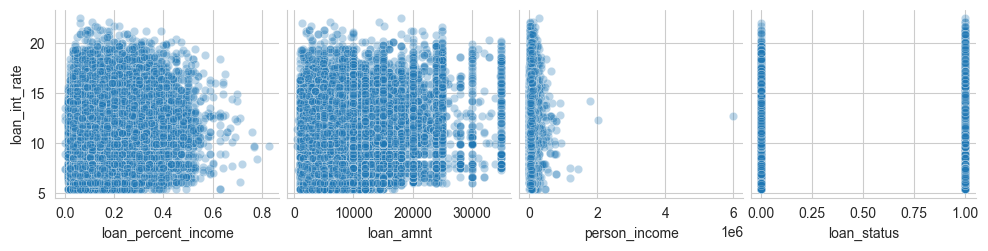

In [64]:
# Select important features for regression target
important_cols_reg = ['loan_percent_income', 'loan_amnt', 
                      'person_income', 'loan_status',
                      'loan_int_rate']  # target

# Pairplot with hue by loan_int_rate is continuous
# so we cannot use hue directly
# Instead use loan_status as hue
sns.pairplot(df_eda[important_cols_reg].dropna(),
             y_vars=['loan_int_rate'],
             x_vars=['loan_percent_income', 'loan_amnt',
                     'person_income', 'loan_status'],
             plot_kws={'alpha': 0.3})
plt.savefig('../logs/reports/figures/pairplot_regression_features.png')
plt.show()

In [ ]:
'''
Pairplot for Regression:
Feature                         Relationship with loan_int_rate
loan_percent_income             Slight positive — higher % = higher rate
loan_amnt                       Slight positive — larger loan = higher rate
person_income                   Weak — extreme outliers dominate
loan_status                     Clear difference — defaulters have higher rates
'''

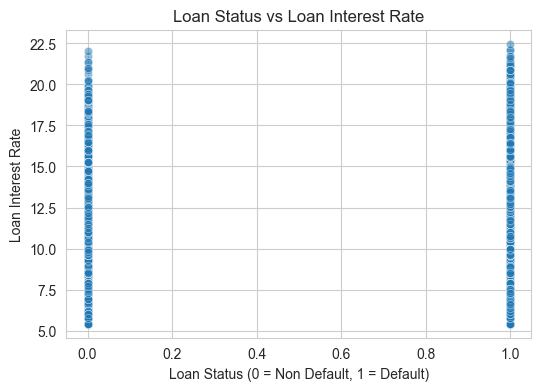

In [65]:
# loan_status vs loan_int_rate
# Most correlated numerical feature with regression target
sns.scatterplot(data=df_eda, 
                x='loan_status',
                y='loan_int_rate',
                alpha=0.5)
plt.title('Loan Status vs Loan Interest Rate')
plt.xlabel('Loan Status (0 = Non Default, 1 = Default)')
plt.ylabel('Loan Interest Rate')
plt.savefig('../logs/reports/figures/loan_status_vs_loan_int_rate.png')
plt.show()

In [ ]:
'''
Scatterplot loan_status vs loan_int_rate:

Status 1 (default) cluster is shifted higher than status 0
Confirms loan_status is strongest numerical predictor for regression
'''

"""
Important Conclusion:

For regression — loan_grade (categorical) is best predictor
Among numerical — loan_status is strongest
This makes business sense — defaulters get higher rates
"""

### Step 13: Important Features Identification

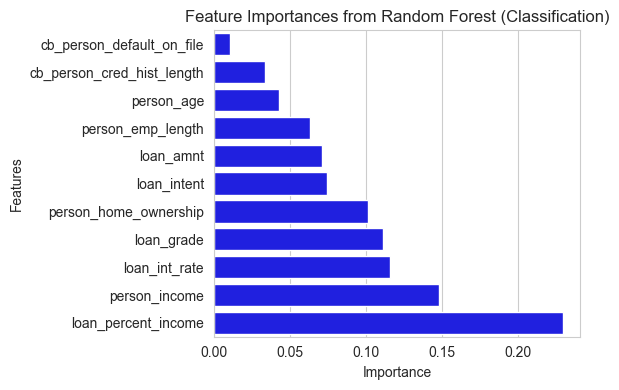

In [70]:
# Use a quick Random Forest to get feature importance
# for classification target (loan_status)

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

rf_cls = RandomForestClassifier(n_estimators=100, random_state=42)

df_rf = df_eda.copy()

# Encode categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    df_rf[col] = le.fit_transform(df_rf[col].astype(str))

# Fill missing values with median
for col in numerical_cols:
    df_rf[col] = df_rf[col].fillna(df_rf[col].median())
    
X_rf = df_rf.drop('loan_status', axis=1)
y_rf = df_rf['loan_status']
rf_cls.fit(X_rf, y_rf)

importances = rf_cls.feature_importances_
feature_names = X_rf.columns

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=True)

sns.barplot(x='Importance', y='Feature', data=feat_imp_df, color='blue')
plt.title('Feature Importances from Random Forest (Classification)')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


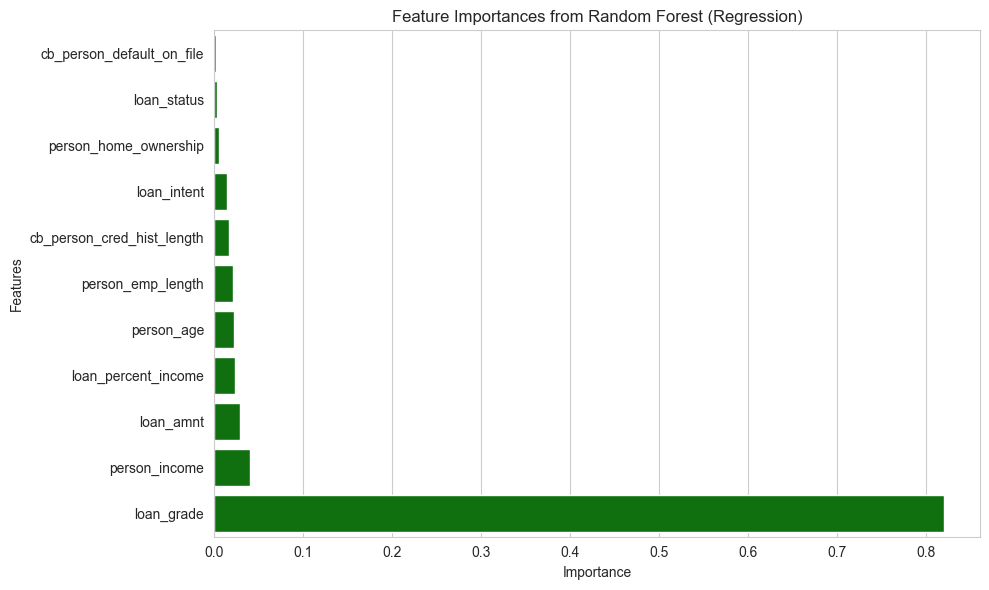

In [71]:
# for regression target (loan_int_rate)

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

rf_reg = RandomForestRegressor(n_estimators=100,random_state=42)

df_rf_reg = df_eda.copy()

# Encode categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    df_rf_reg[col] = le.fit_transform(df_rf_reg[col].astype(str))

# Fill missing values with median
for col in numerical_cols:
    df_rf_reg[col] = df_rf_reg[col].fillna(df_rf_reg[col].median())

X_rf_reg = df_rf_reg.drop('loan_int_rate', axis=1)
y_rf_reg = df_rf_reg['loan_int_rate']
rf_reg.fit(X_rf_reg, y_rf_reg)

importances_reg = rf_reg.feature_importances_
feature_names_reg = X_rf_reg.columns

feat_imp_reg_df = pd.DataFrame({'Feature': feature_names_reg, 'Importance': importances_reg})
feat_imp_reg_df = feat_imp_reg_df.sort_values(by='Importance', ascending=True)

sns.barplot(x='Importance', y='Feature', data=feat_imp_reg_df, color    ='green')
plt.title('Feature Importances from Random Forest (Regression)')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [68]:
# Print top 5 features for each model
# Classification top 5
# Regression top 5

print("Top 5 Features for Classification:")
print(feat_imp_df.sort_values(by='Importance', ascending=False).head(5))

print("\nTop 5 Features for Regression:")
print(feat_imp_reg_df.sort_values(by='Importance', ascending=False).head(5))

Top 5 Features for Classification:
                 Feature  Importance
8    loan_percent_income    0.229058
1          person_income    0.147568
7          loan_int_rate    0.115402
5             loan_grade    0.110829
2  person_home_ownership    0.101471

Top 5 Features for Regression:
               Feature  Importance
5           loan_grade    0.819227
1        person_income    0.040708
6            loan_amnt    0.029617
7  loan_percent_income    0.023550
0           person_age    0.022822


In [ ]:
'''
Critical Insights:

loan_grade dominates regression — 82% importance alone
loan_percent_income is strongest for classification
Both models confirm loan_grade is extremely important
'''

### Step 14: Business Insights Summary

## Business Insights from EDA

### Dataset Overview
- 27,693 training samples with 12 features
- 2 missing columns: person_emp_length (2.81%) 
  and loan_int_rate (9.56%)
- 7,319 outliers detected across 7 numerical columns

### Target Variable Insights
- loan_status: 78.18% non-default vs 21.82% default
  — class imbalance needs handling
- loan_int_rate: bimodal distribution — 2 borrower 
  groups exist (low risk ~7.5% and high risk ~13%)

### Most Important Features
- Classification: loan_percent_income (22.9%), 
  person_income (14.8%), loan_int_rate (11.5%),
  loan_grade (11.1%), person_home_ownership (10.1%)
- Regression: loan_grade (81.9%), person_income (4.1%),
  loan_amnt (3.0%), loan_percent_income (2.4%)

### Risk Indicators
- High risk profile: RENT owner + DEBTCONSOLIDATION 
  intent + grade D-G + loan >40% of income
  → default rate can reach 98% (grade G)
- Low risk profile: MORTGAGE/OWN + grade A-B 
  + loan <15% of income
  → default rate as low as 7-10%

### Actionable Insights for Bank
- Reject all grade G applicants (98% default rate)
- Flag RENT applicants with loan >40% of income
- Prioritize grade A-B applicants for approval
- High interest rate = high default risk — monitor closely
- Past default history (Y) doubles default probability

### Features to Watch in Preprocessing
- person_income: extreme skewness (35.69) 
  → needs log transformation
- person_age: max=144 → needs capping
- person_emp_length: max=123 → needs capping
- person_age & cb_person_cred_hist_length: 
  correlation=0.85 → consider dropping one

### Step 15: Save all plots

In [69]:
# already save above

### Step 16: EDA Report

In [70]:
# see docs/eda_report.md